In [2]:
# 1. Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Loading Dataset
df = pd.read_csv("Student Performance Data1.csv")
df

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,high,Poor,Public,No,Medium,High,NaN,28.0,1,Positive,Low,Yes,1,Average,64
1,4,53,99,1,8,LOW,Average,Private,Yes,Low,High,School,NaN,2,Neutral,Low,Yes,2,Good,71
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,NaN,3,Neutral,Low,No,4,Poor,95
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,95
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6603,7,45,81,2,4,Medium,Average,Public,Yes,Medium,High,Graduate,3.0,1,Positive,Medium,No,3,Average,66
6604,5,58,79,2,7,Low,Average,Private,No,Low,Low,School,16.0,0,Neutral,Medium,Yes,5,Average,69
6605,7,82,63,1,7,Medium,Average,Public,Yes,Medium,High,School,15.0,2,Negative,Low,No,4,Average,78
6606,2,80,65,4,7,Medium,NaN,Private,Yes,Low,Low,School,5.0,2,Negative,Medium,No,1,Good,70


In [3]:
# 3. Basic Overview

print("Shape:", df.shape)
print("\nInfo:\n")
print("\nMissing Values:\n","\n", df.isnull().sum())
print(df.info())
print(df.describe())

Shape: (6608, 20)

Info:


Missing Values:
 
 Hours_Studied                   0
Attendance                      0
Previous_Scores                 0
Tutoring_Sessions               0
Sleep_Hours                     0
Motivation_Level                0
Teacher_Quality               661
School_Type                     0
Internet_Access                 0
Family_Income                   0
Parental_Involvement            0
Parental_Education_Level      661
Distance_from_Home            661
Physical_Activity               0
Peer_Influence                  0
Access_to_Resources             0
Extracurricular_Activities      0
Health                          0
Study_Environment               0
Exam_Score                      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6608 non-null   in

In [4]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions  Sleep_Hours  \
0              7          53               58                  3            8   
1              4          53               99                  1            8   
2             60          55               88                  2            9   
3              8          46               93                  2           20   
4              5          71               53                  0            5   

  Motivation_Level Teacher_Quality School_Type Internet_Access Family_Income  \
0             high            Poor      Public              No        Medium   
1              LOW         Average     Private             Yes           Low   
2           Medium            Poor     Private              No           Low   
3             High            Good     Private             Yes        Medium   
4             High            Good     Private              No        Medium   

  Parental_Invol

In [5]:
# df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6608 non-null   int64  
 1   Attendance                  6608 non-null   int64  
 2   Previous_Scores             6608 non-null   int64  
 3   Tutoring_Sessions           6608 non-null   int64  
 4   Sleep_Hours                 6608 non-null   int64  
 5   Motivation_Level            6608 non-null   str    
 6   Teacher_Quality             5947 non-null   str    
 7   School_Type                 6608 non-null   str    
 8   Internet_Access             6608 non-null   str    
 9   Family_Income               6608 non-null   str    
 10  Parental_Involvement        6608 non-null   str    
 11  Parental_Education_Level    5947 non-null   str    
 12  Distance_from_Home          5947 non-null   float64
 13  Physical_Activity           6608 non-null   

In [6]:
# 4. Handle Missing Values
df['Teacher_Quality'] = df['Teacher_Quality'].fillna('Average')
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna('Graduate')
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mean())

# Standardizing categorical data 
df['Motivation_Level'] = df['Motivation_Level'].str.capitalize()
df['Internet_Access'] = df['Internet_Access'].str.capitalize()

In [7]:
# Removing unrealistic values 
df = df[(df["Hours_Studied"] <= 24) & (df["Sleep_Hours"] <= 24)]

In [8]:
# Creating Score Range
bins = [0, 60, 80, 90, 100]
labels = ["Below 60", "60-80", "81-90", "91-100"]

df["Score_Range"] = pd.cut(df["Exam_Score"], bins=bins, labels=labels, include_lowest=True)

In [9]:
# 5. Convert ALL columns to integers (Manual Encoding)

for col in df.columns:
    df[col] = pd.Categorical(df[col]).codes
df

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,...,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score,Score_Range
0,6,13,28,3,5,0,2,1,0,2,...,0,28,1,2,1,1,0,0,24,1
1,3,13,69,1,5,1,0,0,1,1,...,2,14,2,1,1,1,1,1,31,1
3,7,6,63,2,7,0,1,0,1,2,...,0,2,3,0,1,0,1,2,55,3
4,4,31,23,0,2,0,1,0,0,2,...,1,20,4,2,0,1,0,2,26,1
5,6,18,15,2,1,2,2,0,1,2,...,1,3,6,1,2,0,1,2,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6603,6,5,51,2,1,2,0,1,1,2,...,0,2,1,2,2,0,2,0,26,1
6604,4,18,49,2,4,1,0,0,0,1,...,2,16,0,1,2,1,4,0,29,1
6605,6,42,33,1,4,2,0,1,1,2,...,2,15,2,0,1,0,3,0,38,1
6606,1,40,35,4,4,2,0,0,1,1,...,2,4,2,0,2,0,0,1,30,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 6607 entries, 0 to 6607
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int8 
 1   Attendance                  6607 non-null   int8 
 2   Previous_Scores             6607 non-null   int8 
 3   Tutoring_Sessions           6607 non-null   int8 
 4   Sleep_Hours                 6607 non-null   int8 
 5   Motivation_Level            6607 non-null   int8 
 6   Teacher_Quality             6607 non-null   int8 
 7   School_Type                 6607 non-null   int8 
 8   Internet_Access             6607 non-null   int8 
 9   Family_Income               6607 non-null   int8 
 10  Parental_Involvement        6607 non-null   int8 
 11  Parental_Education_Level    6607 non-null   int8 
 12  Distance_from_Home          6607 non-null   int8 
 13  Physical_Activity           6607 non-null   int8 
 14  Peer_Influence          

In [11]:
print("\nAfter Encoding:\n", df.head())
print(df.info())


After Encoding:
    Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions  Sleep_Hours  \
0              6          13               28                  3            5   
1              3          13               69                  1            5   
3              7           6               63                  2            7   
4              4          31               23                  0            2   
5              6          18               15                  2            1   

   Motivation_Level  Teacher_Quality  School_Type  Internet_Access  \
0                 0                2            1                0   
1                 1                0            0                1   
3                 0                1            0                1   
4                 0                1            0                0   
5                 2                2            0                1   

   Family_Income  ...  Parental_Education_Level  Distance_from_Home  \
0  

In [12]:
# 6. Basic Statistics

print("\nStatistics:\n", df.describe())


Statistics:
        Hours_Studied   Attendance  Previous_Scores  Tutoring_Sessions  \
count    6607.000000  6607.000000      6607.000000        6607.000000   
mean        4.965037    29.134857        34.315272           2.006811   
std         3.152759    17.311953        20.099564           1.413822   
min         0.000000     0.000000         0.000000           0.000000   
25%         2.000000    14.000000        17.000000           1.000000   
50%         5.000000    29.000000        34.000000           2.000000   
75%         8.000000    44.000000        51.000000           3.000000   
max        10.000000    59.000000        69.000000           4.000000   

       Sleep_Hours  Motivation_Level  Teacher_Quality  School_Type  \
count  6607.000000       6607.000000      6607.000000  6607.000000   
mean      3.021644          0.985621         0.883154     0.488573   
std       1.985030          0.818315         0.828624     0.499907   
min       0.000000          0.000000         0.0

In [13]:
# # 7. Correlation Matrix
# corr = df.corr()
# corr

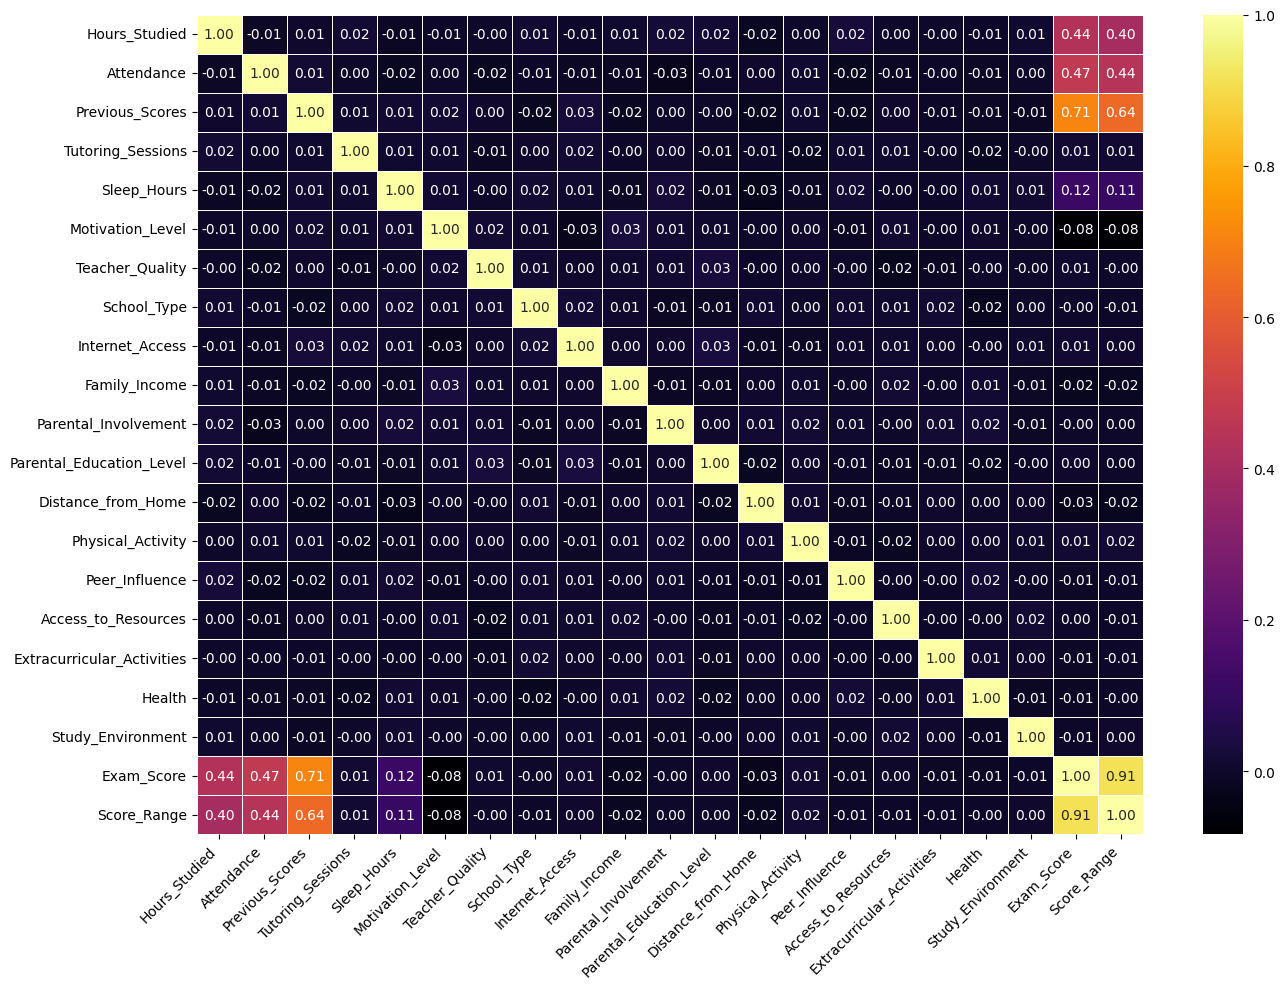

In [14]:
# 8. HEATMAP (MAIN OUTPUT)

plt.figure(figsize=(14, 10))

sns.heatmap(df.corr(),annot=True, cmap='inferno', linewidths=0.5, fmt=".2f")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

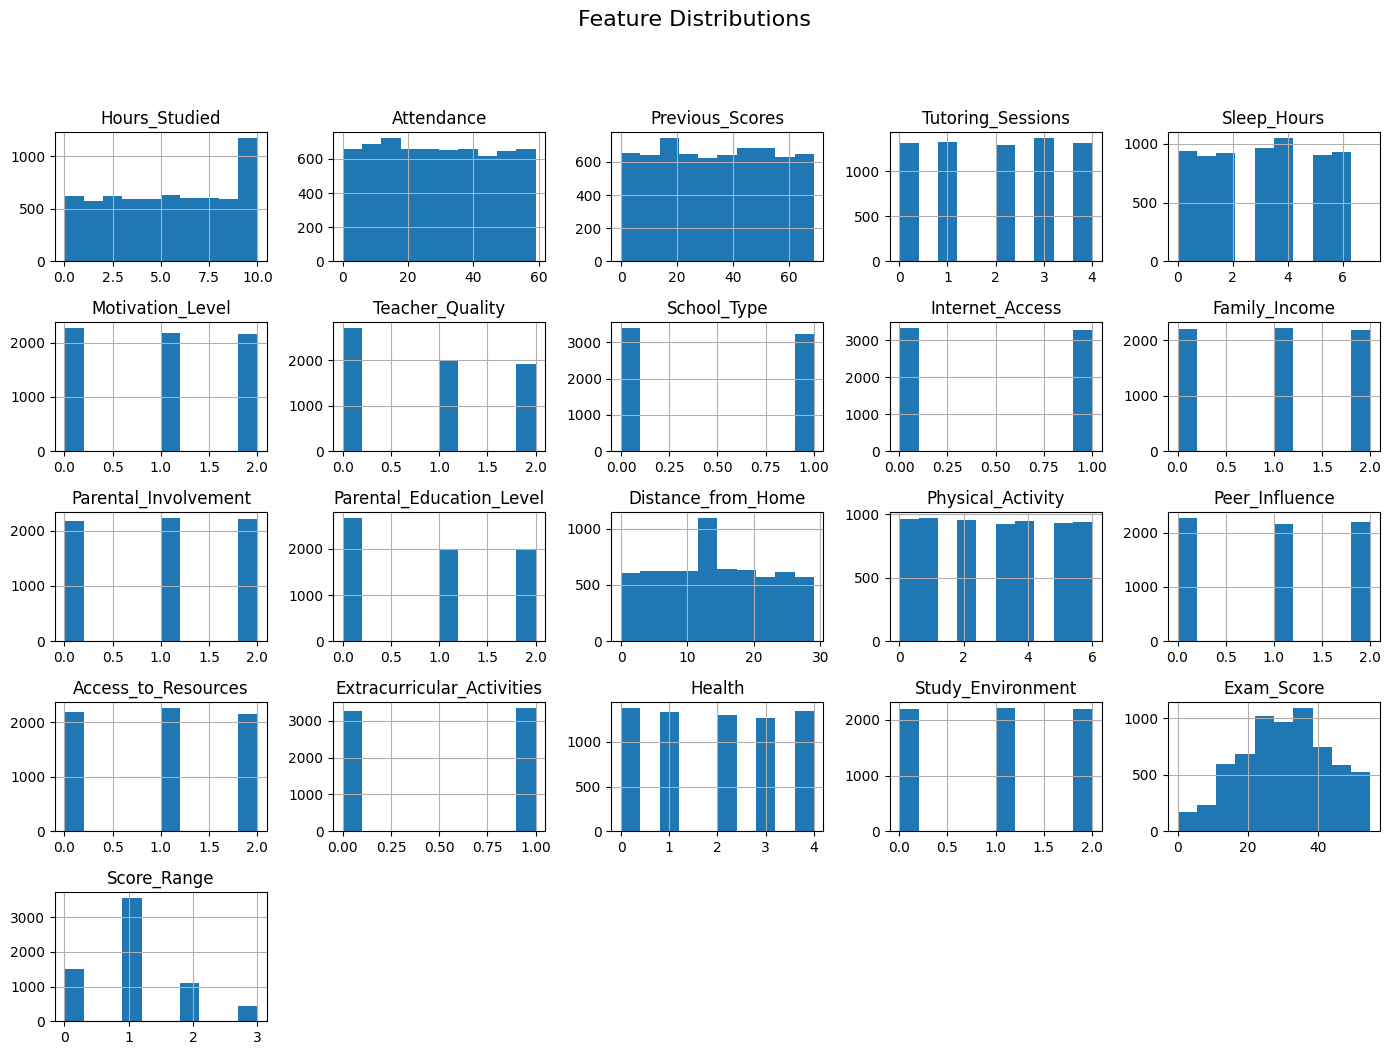

In [15]:
# 9. Histograms (Distribution)

df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

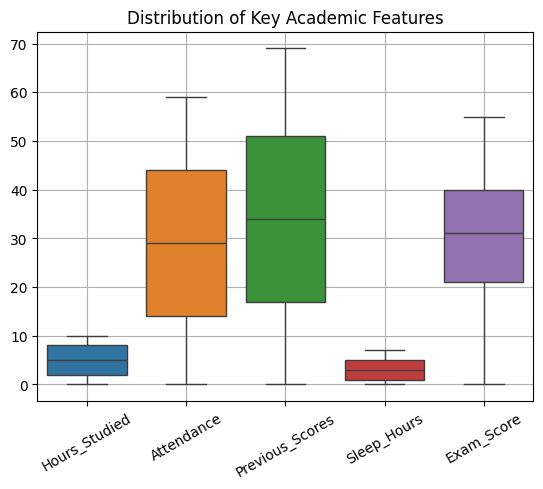

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of main numeric features
sns.boxplot(data=df[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Sleep_Hours', 'Exam_Score']])

plt.title('Distribution of Key Academic Features')
plt.xticks(rotation=30)
plt.grid()
plt.show()

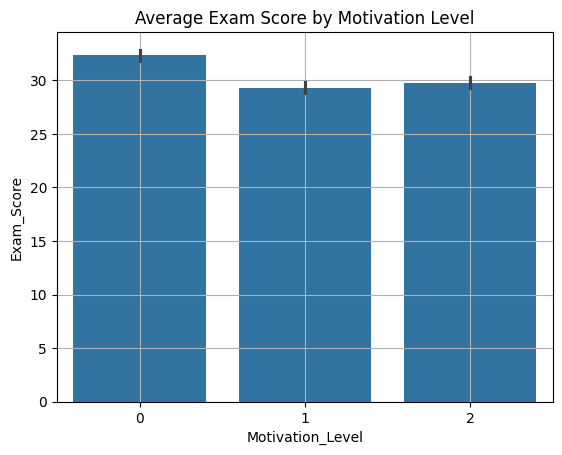

In [17]:
import seaborn as sns

sns.barplot(x='Motivation_Level', y='Exam_Score', data=df)

plt.title('Average Exam Score by Motivation Level')
plt.grid()
plt.show()

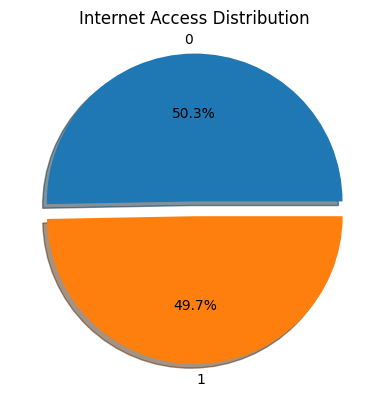

In [18]:
internet_counts = df['Internet_Access'].value_counts()

explode = (0.1, 0)  # highlight first slice

plt.pie(internet_counts,
        labels=internet_counts.index,
        autopct='%1.1f%%',
        explode=explode,
        shadow=True)

plt.title('Internet Access Distribution')
plt.show()

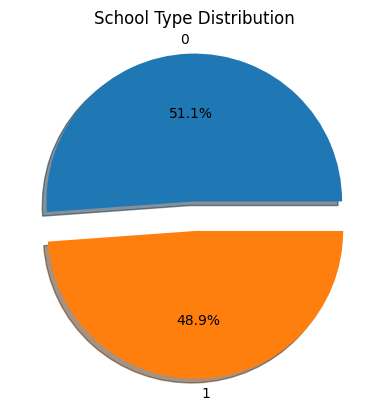

In [19]:
school_counts = df['School_Type'].value_counts()

explode = (0.1, 0.1)

plt.pie(school_counts,
        labels=school_counts.index,
        autopct='%1.1f%%',
        explode=explode,
        shadow=True)

plt.title('School Type Distribution')
plt.show()

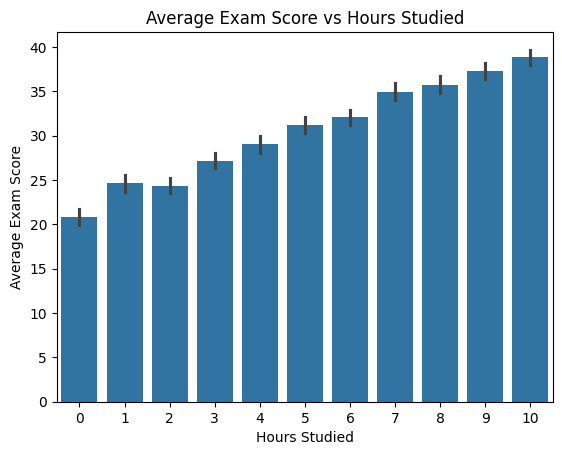

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Hours_Studied', y='Exam_Score', data=df)

plt.title('Average Exam Score vs Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Average Exam Score')

plt.show()

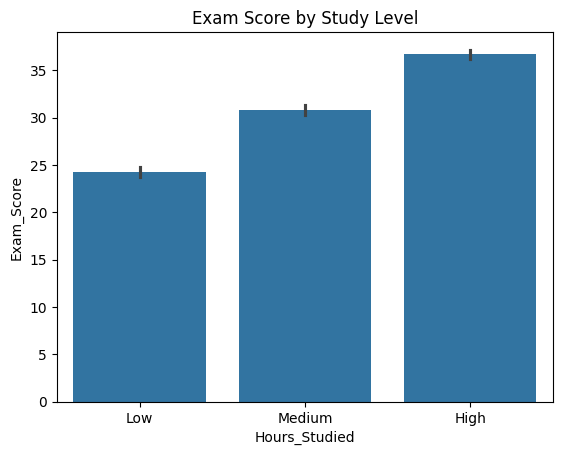

In [21]:
# Create categories
df['Hours_Studied'] = pd.cut(df['Hours_Studied'], bins=3, labels=['Low', 'Medium', 'High'])

sns.barplot(x='Hours_Studied', y='Exam_Score', data=df)

plt.title('Exam Score by Study Level')
plt.show()

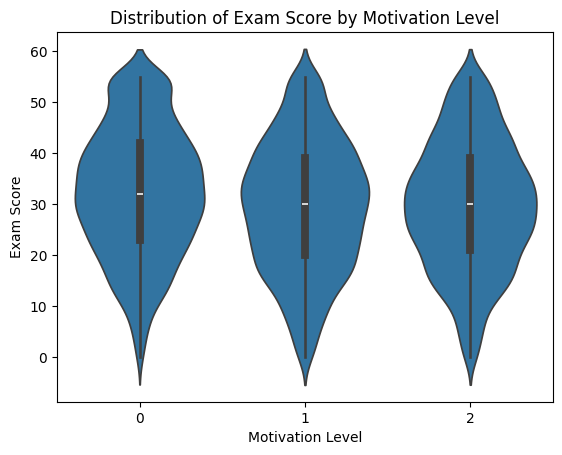

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='Motivation_Level', y='Exam_Score', data=df)

plt.title('Distribution of Exam Score by Motivation Level')
plt.xlabel('Motivation Level')
plt.ylabel('Exam Score')

plt.show()

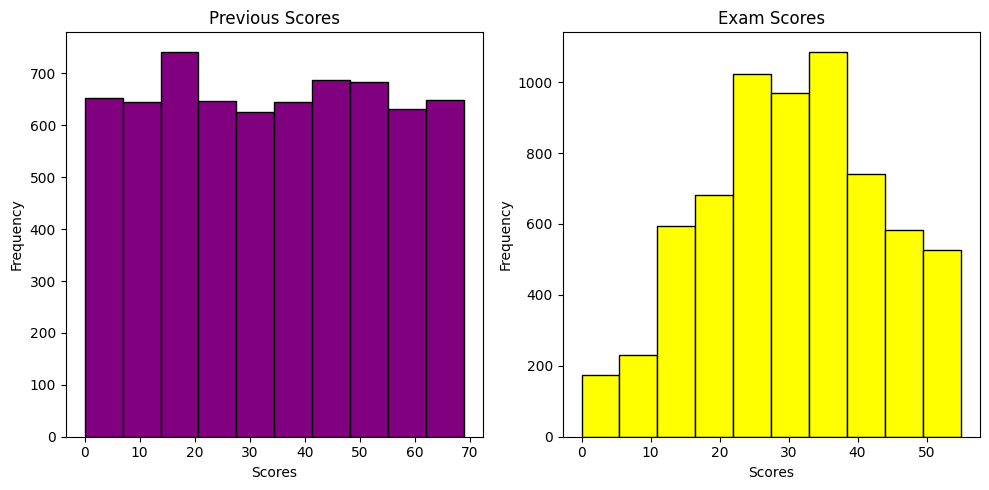

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# First subplot (Previous Scores)
plt.subplot(1, 2, 1)
plt.hist(df['Previous_Scores'], bins=10, color='purple', edgecolor='black')
plt.title('Previous Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')

# Second subplot (Exam Scores)
plt.subplot(1, 2, 2)
plt.hist(df['Exam_Score'], bins=10, color='yellow', edgecolor='black')
plt.title('Exam Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
plt.hist(df['Exam_Score'], bins=10, color='orange', edgecolor='black')
plt.title('Histogram of Exam Scores')
plt.xlabel('Exam Scores')
plt.ylabel('Frequency')
plt.grid()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df, color='green')

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.scatterplot(x='Attendance', y='Exam_Score', data=df, color='orange')

plt.title('Attendance vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(color = 'black')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Temporary mapping
mapping = {
    0: 'School',
    1: 'College',
    2: 'Higher Education'
}

# Apply mapping temporarily
mapped = df['Parental_Education_Level'].map(mapping)

# Count values
counts = mapped.value_counts()

# Colors
colors = ['orange', 'green', 'red'] * (len(counts)//3 + 1)

# Explode all slices slightly
explode = [0.05] * len(counts)

plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colors[:len(counts)],
        explode=explode)

plt.title('Parental Education Level Distribution')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Tutoring_Sessions',
            y='Exam_Score',
            data=df,
            color='navy')

plt.title('Average Exam Score by Tutoring Sessions')
plt.xlabel('Tutoring Sessions')
plt.ylabel('Average Exam Score')

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

mapped = df['Tutoring_Sessions'].map(mapping)

sns.barplot(x=mapped,
            y=df['Exam_Score'],
            color='orange')

plt.title('Tutoring Sessions vs Exam Score')
plt.xlabel('Tutoring Level')
plt.ylabel('Average Exam Score')

plt.grid(axis='x')   # <-- only horizontal lines

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional mapping (if values are 0,1,2)
parent_map = {0: 'School', 1: 'College', 2: 'Higher'}
motivation_map = {0: 'Low', 1: 'Medium', 2: 'High'}

df['Parent_Edu_mapped'] = df['Parental_Education_Level'].map(parent_map)
df['Motivation_mapped'] = df['Motivation_Level'].map(motivation_map)

sns.countplot(x='Parent_Edu_mapped',
              hue='Motivation_mapped',
              data=df)

plt.title('Motivation Level across Parental Education')
plt.xlabel('Parental Education Level')
plt.ylabel('Number of Students')

plt.grid(axis='y')
plt.legend(title='Motivation Level', loc='upper right')

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional mapping (if encoded as 0/1)
mapping = {0: 'No', 1: 'Yes'}
mapped = df['Internet_Access'].map(mapping)

sns.barplot(x=mapped,
            y=df['Exam_Score'],
            palette='Set2')

plt.title('Exam Score by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Average Exam Score')

plt.grid(axis='x')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='Extracurricular_Activities', y='Exam_Score', data=df, palette='Set2')
plt.title('Distribution of Exam Score by Motivation Level')
plt.xlabel('Motivation Level')
plt.ylabel('Exam Score')
plt.show()

In [ ]:
df.info()

In [ ]:
df.to_csv("refined_dataset.csv", index=False)

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# =========================
# DEFINE X AND y
# =========================
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# =========================
# ENCODING
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# METRICS
# =========================
print("📊 MODEL PERFORMANCE")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# =========================
# GRAPH: ACTUAL vs PREDICTED
# =========================
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Exam Score", fontsize=14, fontweight='bold')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
# =========================
# SAVE MODEL
# =========================
joblib.dump(model, "student_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

print("\n✅ Model saved successfully!")